In [42]:
import pandas
from matplotlib import pyplot
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

In [43]:
def show_samples(length_counter, labels):
    for k,v in length_counter.items():
       percent = v / len(labels)* 100
       print('Class=%d, Number_of_samples %d (%.3f%%)' % (k, v, percent))
    
    return

Class=3, Number_of_samples 119 (22.973%)
Class=2, Number_of_samples 74 (14.286%)
Class=6, Number_of_samples 74 (14.286%)
Class=4, Number_of_samples 90 (17.375%)
Class=5, Number_of_samples 43 (8.301%)
Class=1, Number_of_samples 44 (8.494%)
Class=0, Number_of_samples 74 (14.286%)


c:\ProjetosIC\JulioAvilaS-FIP-2025-classificacao-automatica-falhas-transformadores-potencia\ambiente_teste\lib\site-packages\sklearn\preprocessing\_label.py:115: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


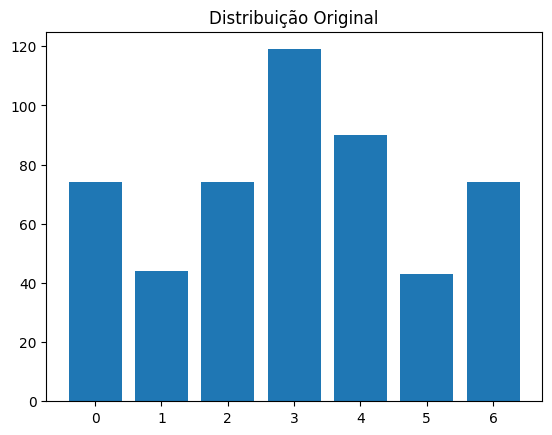

In [44]:
origin_samples_file = "Datasets/Ibrahim-dataset/Entire-dataset/test_samples.csv"
origin_labels_file = "Datasets/Ibrahim-dataset/Entire-dataset/test_labels.csv"

df = pandas.read_csv(origin_samples_file)
samples = df.values.tolist()

df = pandas.read_csv(origin_labels_file)
labels = df.values.tolist()

labels = LabelEncoder().fit_transform(labels)

length_counter = Counter(labels)

show_samples(length_counter, labels)

pyplot.bar(length_counter.keys(), length_counter.values())
pyplot.title("Distribuição Original")
pyplot.show()


Class=3, Number_of_samples 119 (14.286%)
Class=2, Number_of_samples 119 (14.286%)
Class=6, Number_of_samples 119 (14.286%)
Class=4, Number_of_samples 119 (14.286%)
Class=5, Number_of_samples 119 (14.286%)
Class=1, Number_of_samples 119 (14.286%)
Class=0, Number_of_samples 119 (14.286%)


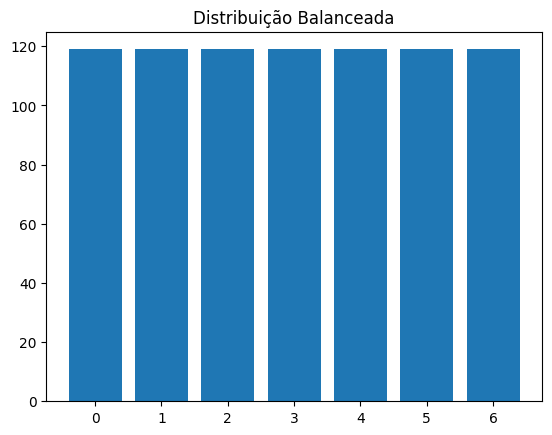

In [45]:
oversample = SMOTE()
samples_balanced, labels_balanced = oversample.fit_resample(samples, labels)

length_counter = Counter(labels_balanced)

show_samples(length_counter, labels_balanced)

pyplot.bar(length_counter.keys(), length_counter.values())
pyplot.title("Distribuição Balanceada")
pyplot.show()

In [46]:
balanced_df = pandas.DataFrame(samples_balanced)
balanced_df.columns = ['h2', 'ch4', 'c2h2', 'c2h4', 'c2h6']
balanced_df['act'] = labels_balanced

output_file = "Datasets/Ibrahim-dataset/Oversampled-119-dataset/entire_dataset.csv"
balanced_df.to_csv(output_file, index=False)